<a href="https://colab.research.google.com/github/josidimufrj/geo_modelagem/blob/main/Parte1_Cartopy__opernicus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parte 1 – Mapeamento climático da região produtora de açaí

mapa do Estado do Pará utilizando a biblioteca Cartopy em Python. No mapa, deverá ser destacada a principal região produtora de açaí, considerando municípios como Igarapé-Miri, Cametá, Abaetetuba e entorno.

In [30]:
!pip install cartopy
import cartopy

In [31]:
!pip install matplotlib-scalebar

/tmp/ipykernel_1230/2697912697.py:70: UserWarning: Legend does not support handles for FeatureArtist instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(loc='lower left', fontsize=10)


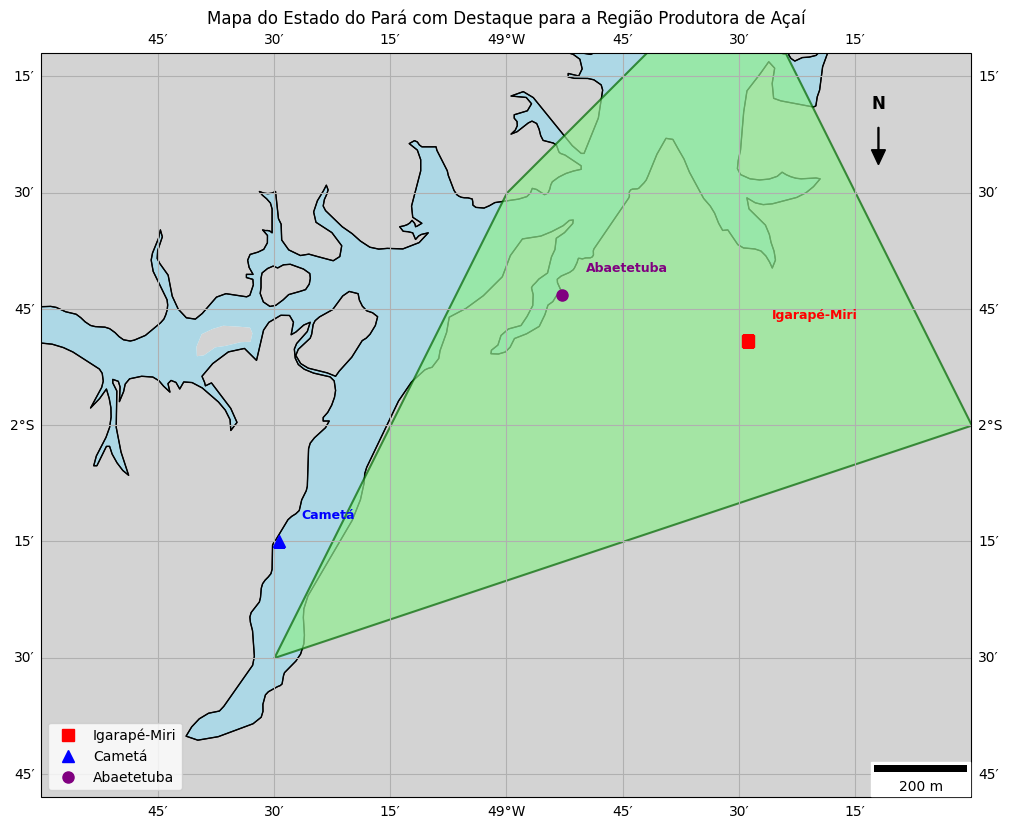

In [32]:
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
from shapely.geometry import Polygon # Para definir a região do açaí
from matplotlib_scalebar.scalebar import ScaleBar # Importa ScaleBar

fig = plt.figure(figsize=(12, 10)) # Aumenta o tamanho da figura para melhor visualização
ax = plt.axes(projection=ccrs.PlateCarree()) # Projeção de Plate Carrée

# 🌍 Adiciona características geográficas
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
ax.coastlines(resolution='10m', linewidth=0.8) # Fronteiras costeiras
ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.5) # Fronteiras de países
ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='black', linewidth=1.0) # Fronteiras de estados (Brasil) - Aumentado o destaque

# Define a extensão do mapa para focar na região produtora de açaí e municípios
# Coordenadas ajustadas para um foco mais apertado na região de interesse
ax.set_extent([-50.0, -48.0, -2.8, -1.2], crs=ccrs.PlateCarree())

# Adiciona linhas de grade para coordenadas
ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

# Define a região produtora de açaí (aproximando com um polígono)
# Coordenadas dos municípios mencionados e entorno para formar um polígono
acai_region_coords = [
    (-49.5, -2.5), # Sudoeste de Cametá
    (-48.0, -2.0), # Sudeste de Igarapé-Miri
    (-48.5, -1.0), # Norte de Igarapé-Miri / Abaetetuba
    (-49.0, -1.5), # Noroeste de Abaetetuba
    (-49.5, -2.5)  # Fecha o polígono
]
acai_polygon = Polygon(acai_region_coords)

# Destaca a região do açaí com um polígono verde
ax.add_geometries([acai_polygon], ccrs.PlateCarree(),
                  facecolor='lightgreen', edgecolor='darkgreen', alpha=0.7,
                  linewidth=1.5, label='Principal Região Produtora de Açaí')

# Adiciona marcadores para os municípios específicos em cores diferentes
# Igarapé-Miri
ax.plot(-48.48, -1.82, 's', color='red', markersize=8, transform=ccrs.PlateCarree(), label='Igarapé-Miri')
ax.text(-48.48 + 0.05, -1.82 + 0.05, 'Igarapé-Miri', transform=ccrs.PlateCarree(), color='red', fontsize=9, fontweight='bold')

# Cametá
ax.plot(-49.49, -2.25, '^', color='blue', markersize=8, transform=ccrs.PlateCarree(), label='Cametá')
ax.text(-49.49 + 0.05, -2.25 + 0.05, 'Cametá', transform=ccrs.PlateCarree(), color='blue', fontsize=9, fontweight='bold')

# Abaetetuba
ax.plot(-48.88, -1.72, 'o', color='purple', markersize=8, transform=ccrs.PlateCarree(), label='Abaetetuba')
ax.text(-48.88 + 0.05, -1.72 + 0.05, 'Abaetetuba', transform=ccrs.PlateCarree(), color='purple', fontsize=9, fontweight='bold')

# Adiciona a escala gráfica
# É importante definir a unidade correta (e.g., 'km' para quilômetros)
scalebar = ScaleBar(1, 'km', location='lower right',
                    frameon=True,
                    color='black',
                    box_color='white')
ax.add_artist(scalebar)

# Adiciona a rosa dos ventos
# Posição aproximada para o canto superior direito
x_north, y_north = 0.9, 0.9 # Coordenadas relativas aos eixos (0 a 1)
ax.text(x_north, y_north + 0.02, 'N', transform=ax.transAxes, ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
ax.arrow(x_north, y_north, 0, -0.05, transform=ax.transAxes, length_includes_head=True,
         head_width=0.015, head_length=0.02, fc='black', ec='black')

plt.title("Mapa do Estado do Pará com Destaque para a Região Produtora de Açaí")
# Ajusta a legenda para não sobrepor a rosa dos ventos ou a escala
plt.legend(loc='lower left', fontsize=10)
plt.show()

## Dados Meteorológicos




In [33]:
%pip install cdsapi


In [34]:
import cdsapi

dataset = "reanalysis-era5-single-levels"
request = {
    "product_type": ["reanalysis"],
    "variable": [
        "10m_u_component_of_wind",
        "10m_v_component_of_wind",
        "2m_dewpoint_temperature",
        "2m_temperature",
        "total_precipitation"
    ],
    "year": ["2024"],
    "month": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12"
    ],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28", "29", "30",
        "31"
    ],
    "time": ["15:00"],
    "data_format": "netcdf",
    "download_format": "unarchived",
    "area": [-1, -50.9, -2.8, -48]
}

client = cdsapi.Client(url='https://cds.climate.copernicus.eu/api', key='3ef2f54f-55b5-4bc3-a62a-b1ed4e74538c')
client.retrieve(dataset, request).download()




2026-07-07 22:16:40,445 INFO Request ID is cfd32fc8-e302-4cc1-bc3e-5298165f513e
INFO:ecmwf.datastores.legacy_client:Request ID is cfd32fc8-e302-4cc1-bc3e-5298165f513e
2026-07-07 22:16:40,640 INFO status has been updated to accepted
INFO:ecmwf.datastores.legacy_client:status has been updated to accepted
2026-07-07 22:17:02,698 INFO status has been updated to running
INFO:ecmwf.datastores.legacy_client:status has been updated to running
2026-07-07 22:17:14,339 INFO status has been updated to successful
INFO:ecmwf.datastores.legacy_client:status has been updated to successful


154337dab6104b3fa3873bd6f448a060.zip:   0%|          | 0.00/446k [00:00<?, ?B/s]

'154337dab6104b3fa3873bd6f448a060.zip'

In [35]:
import xarray as xr
import pandas as pd

In [36]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [37]:
df = xr.open_dataset('https://raw.githubusercontent.com/josidimufrj/geo_modelagem/main/dados/data_stream-oper_stepType-accum.nc',engine='h5netcdf')
df.to_dataframe().reset_index()

,valid_time,latitude,longitude,tp,number,expver
0,2024-01-01 15:00:00,-1.00,-50.75,0.000054,0,0001
1,2024-01-01 15:00:00,-1.00,-50.50,0.000067,0,0001
2,2024-01-01 15:00:00,-1.00,-50.25,0.000093,0,0001
3,2024-01-01 15:00:00,-1.00,-50.00,0.000078,0,0001
4,2024-01-01 15:00:00,-1.00,-49.75,0.000066,0,0001
...,...,...,...,...,...,...
35131,2024-12-31 15:00:00,-2.75,-49.00,0.000074,0,0001
35132,2024-12-31 15:00:00,-2.75,-48.75,0.000094,0,0001
35133,2024-12-31 15:00:00,-2.75,-48.50,0.000181,0,0001
35134,2024-12-31 15:00:00,-2.75,-48.25,0.000152,0,0001


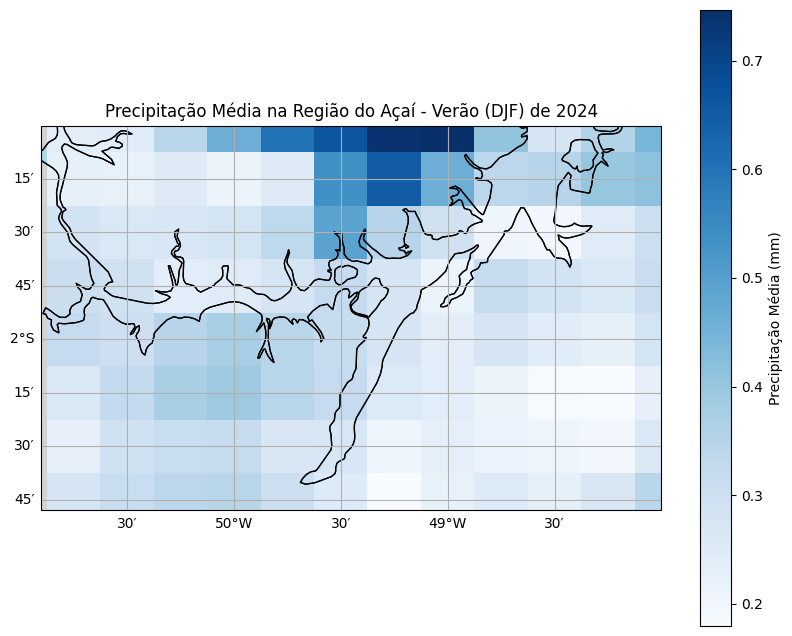

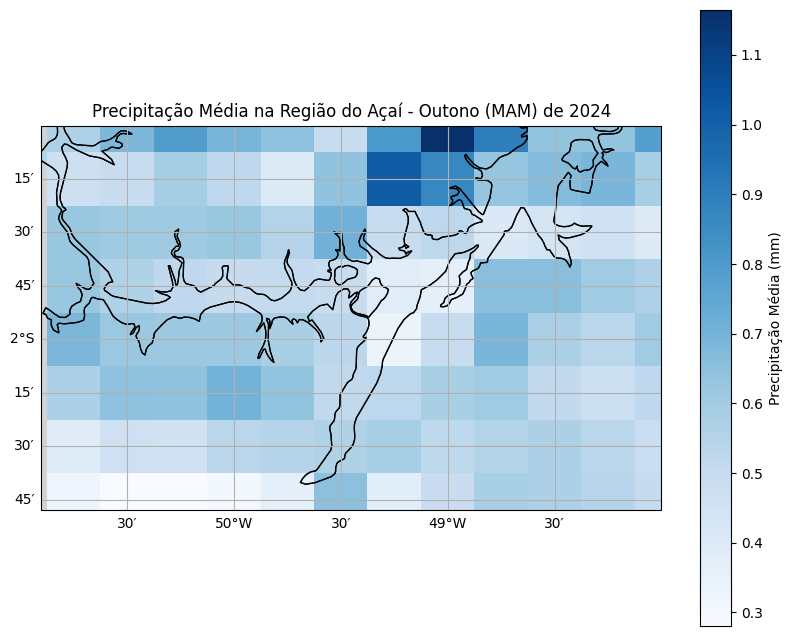

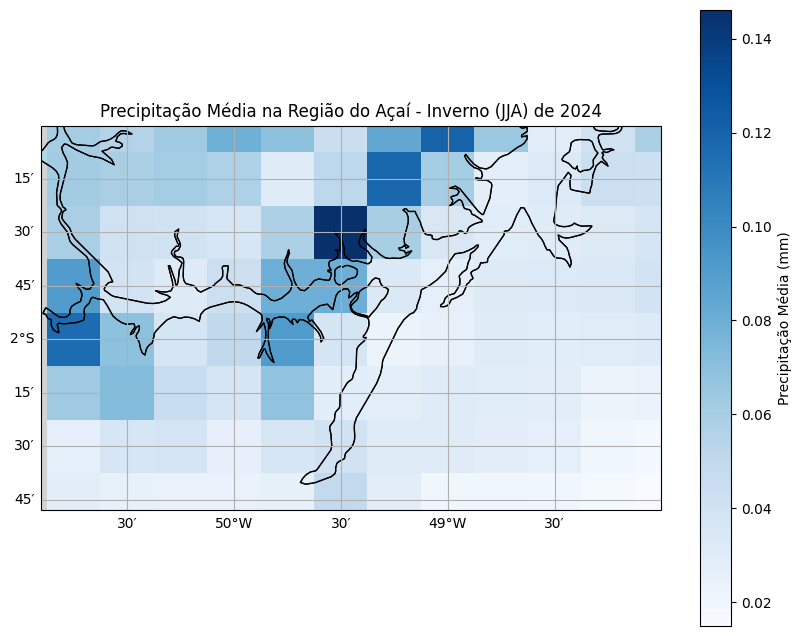

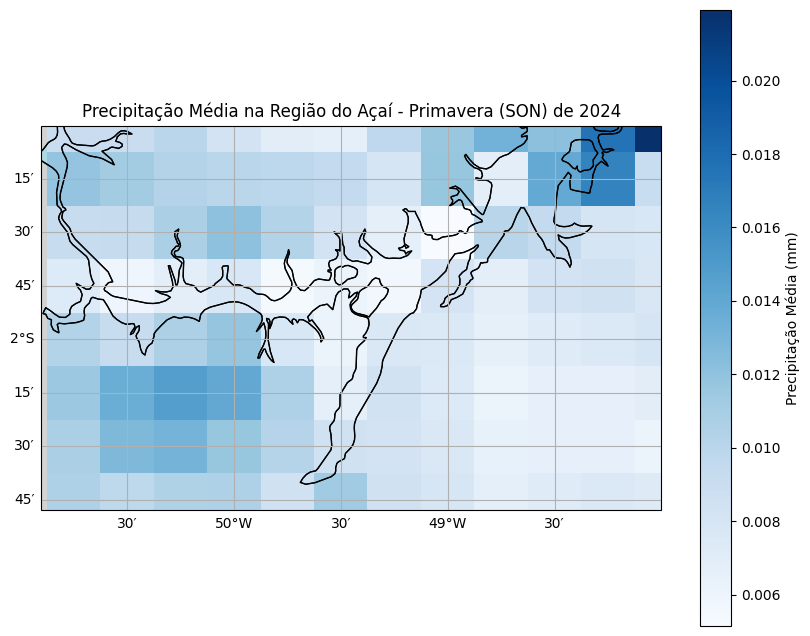

In [38]:
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import xarray as xr
import pandas as pd # Already imported, but good to have explicit imports if needed

# Define seasons with their corresponding months (Brazilian seasons)
seasons = {
    "Verão (DJF)": [12, 1, 2],    # December, January, February
    "Outono (MAM)": [3, 4, 5],     # March, April, May
    "Inverno (JJA)": [6, 7, 8],     # June, July, August
    "Primavera (SON)": [9, 10, 11]  # September, October, November
}

# Define the extent for the maps based on the data request area
# [lon_west, lon_east, lat_south, lat_north]
map_extent = [-50.9, -48, -2.8, -1] # This matches the 'area' requested in cdsapi

for season_name, months in seasons.items():
    # Filter data for the current season
    # Use .dt.month to extract month from valid_time and filter
    seasonal_df = df.sel(valid_time=df['valid_time'].dt.month.isin(months))

    # Calculate the mean total precipitation for the season (and convert to mm)
    # tp is in meters, multiply by 1000 to get millimeters
    seasonal_precip_mm = (seasonal_df['tp'].mean(dim='valid_time')) * 1000

    # Create the plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) # Use PlateCarree projection

    # Set map extent
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())

    # Add geographical features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='black', linewidth=1.0)

    # Plot precipitation data using pcolormesh for gridded data
    # The 'transform' argument is crucial to tell Cartopy that the input data coordinates
    # are in PlateCarree (lon/lat)
    seasonal_precip_mm.plot.pcolormesh(
        ax=ax,
        x='longitude',
        y='latitude',
        cmap='Blues', # 'Blues' colormap is good for precipitation
        cbar_kwargs={'label': 'Precipitação Média (mm)'},
        transform=ccrs.PlateCarree()
    )

    # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False # Hide top latitude labels
    gl.right_labels = False # Hide right longitude labels

    # Add title
    plt.title(f'Precipitação Média na Região do Açaí - {season_name} de 2024')

    plt.show()

### Temperatura

In [39]:
df2 = xr.open_dataset('https://raw.githubusercontent.com/josidimufrj/geo_modelagem/main/dados/data_stream-oper_stepType-instant.nc',engine='h5netcdf')
df2.to_dataframe().reset_index()

,valid_time,latitude,longitude,u10,v10,d2m,t2m,number,expver
0,2024-01-01 15:00:00,-1.00,-50.75,-1.257614,-1.176620,297.385254,304.022705,0,0001
1,2024-01-01 15:00:00,-1.00,-50.50,-0.832809,-0.908066,298.254395,303.413330,0,0001
2,2024-01-01 15:00:00,-1.00,-50.25,-0.180466,-0.717636,299.078613,302.618408,0,0001
3,2024-01-01 15:00:00,-1.00,-50.00,-0.055466,-0.605331,298.766113,302.403564,0,0001
4,2024-01-01 15:00:00,-1.00,-49.75,-0.299606,-0.578964,298.590332,302.173096,0,0001
...,...,...,...,...,...,...,...,...,...
35131,2024-12-31 15:00:00,-2.75,-49.00,-1.105194,0.800385,295.811279,303.972351,0,0001
35132,2024-12-31 15:00:00,-2.75,-48.75,-0.998749,0.726166,295.744873,304.109070,0,0001
35133,2024-12-31 15:00:00,-2.75,-48.50,-0.926483,0.681244,296.530029,304.058289,0,0001
35134,2024-12-31 15:00:00,-2.75,-48.25,-0.901093,0.702728,297.131592,304.212585,0,0001


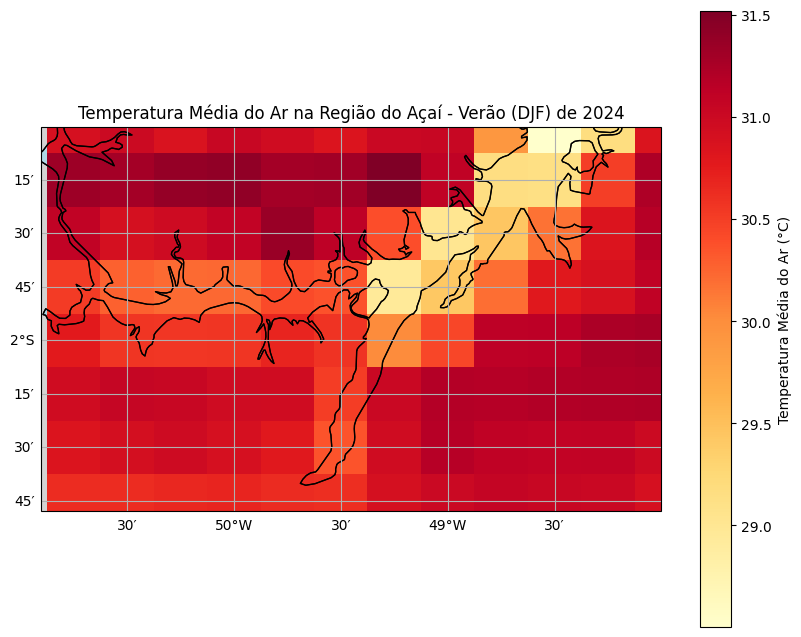

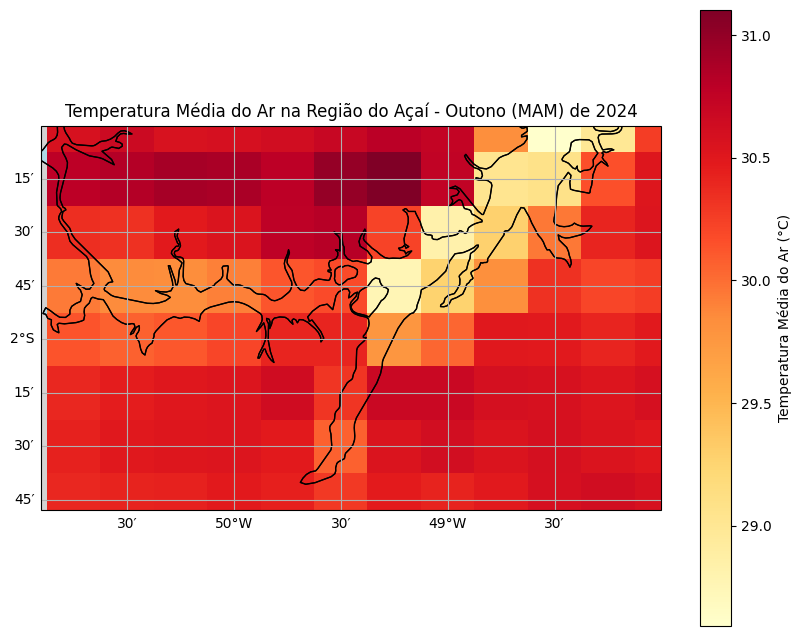

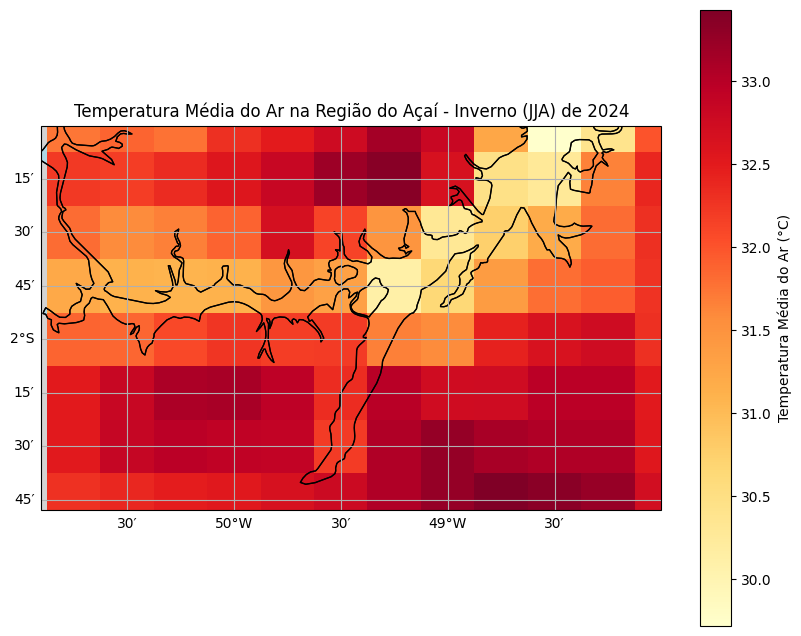

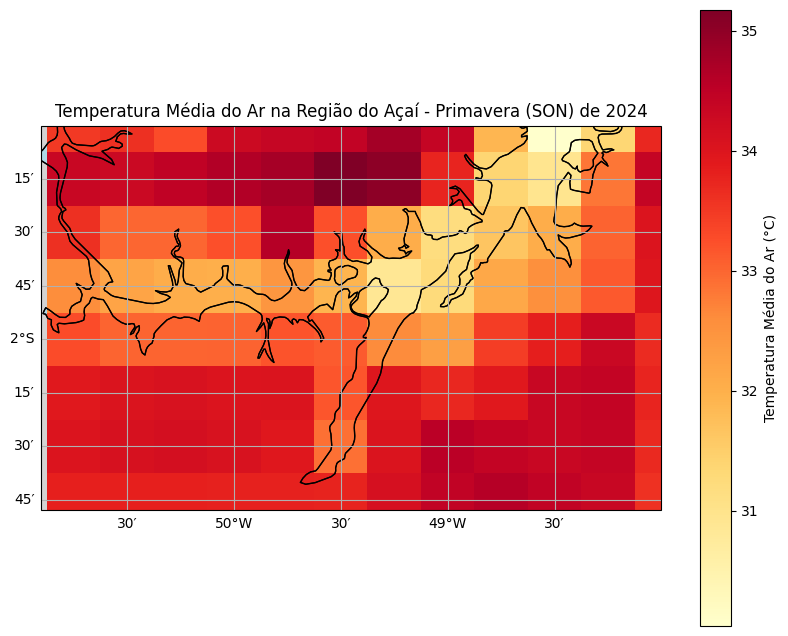

In [40]:
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import xarray as xr
import pandas as pd # Already imported, but good to have explicit imports if needed

# Define seasons with their corresponding months (Brazilian seasons)
seasons = {
    "Verão (DJF)": [12, 1, 2],    # December, January, February
    "Outono (MAM)": [3, 4, 5],     # March, April, May
    "Inverno (JJA)": [6, 7, 8],     # June, July, August
    "Primavera (SON)": [9, 10, 11]  # September, October, November
}

# Define the extent for the maps based on the data request area
# [lon_west, lon_east, lat_south, lat_north]
map_extent = [-50.9, -48, -2.8, -1] # This matches the 'area' requested in cdsapi

for season_name, months in seasons.items():
    # Filter data for the current season
    # Use .dt.month to extract month from valid_time and filter
    # Assuming df is the dataset loaded from data_stream-oper_stepType-instant.nc
    seasonal_df = df2.sel(valid_time=df2['valid_time'].dt.month.isin(months))

    # Calculate the mean 2m temperature for the season (and convert from Kelvin to Celsius)
    # t2m is in Kelvin, subtract 273.15 to get Celsius
    seasonal_temp_celsius = (seasonal_df['t2m'].mean(dim='valid_time')) - 273.15

    # Create the plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) # Use PlateCarree projection

    # Set map extent
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())

    # Add geographical features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='black', linewidth=1.0)

    # Plot temperature data using pcolormesh for gridded data
    # The 'transform' argument is crucial to tell Cartopy that the input data coordinates
    # are in PlateCarree (lon/lat)
    seasonal_temp_celsius.plot.pcolormesh(
        ax=ax,
        x='longitude',
        y='latitude',
        cmap='YlOrRd', # Changed colormap to 'YlOrRd' for darker colors = hotter
        cbar_kwargs={'label': 'Temperatura Média do Ar (°C)'},
        transform=ccrs.PlateCarree()
    )

    # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False # Hide top latitude labels
    gl.right_labels = False # Hide right longitude labels

    # Add title
    plt.title(f'Temperatura Média do Ar na Região do Açaí - {season_name} de 2024')

    plt.show()

### intensidade do vento

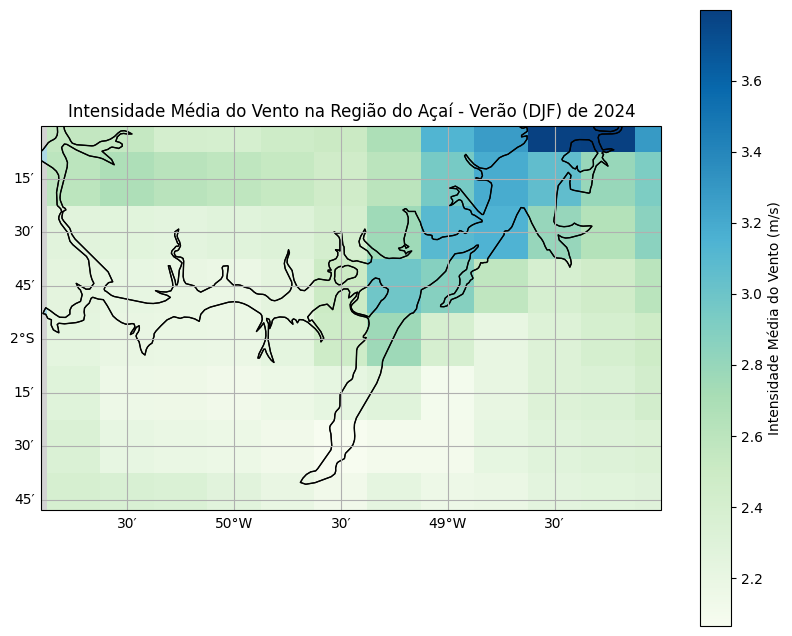

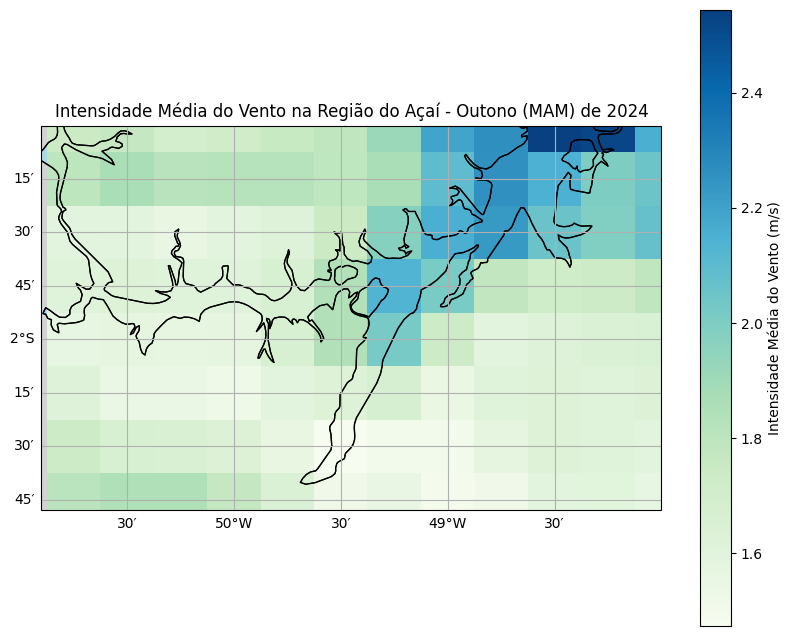

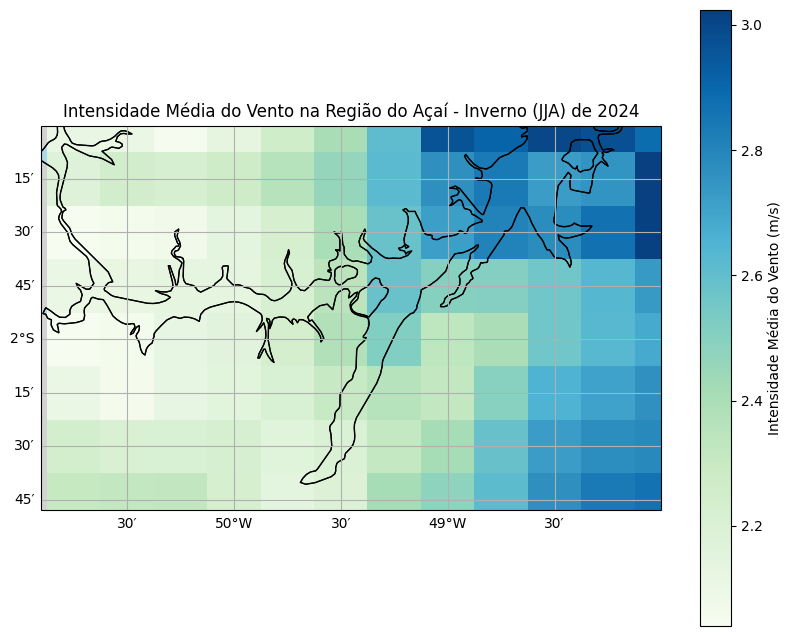

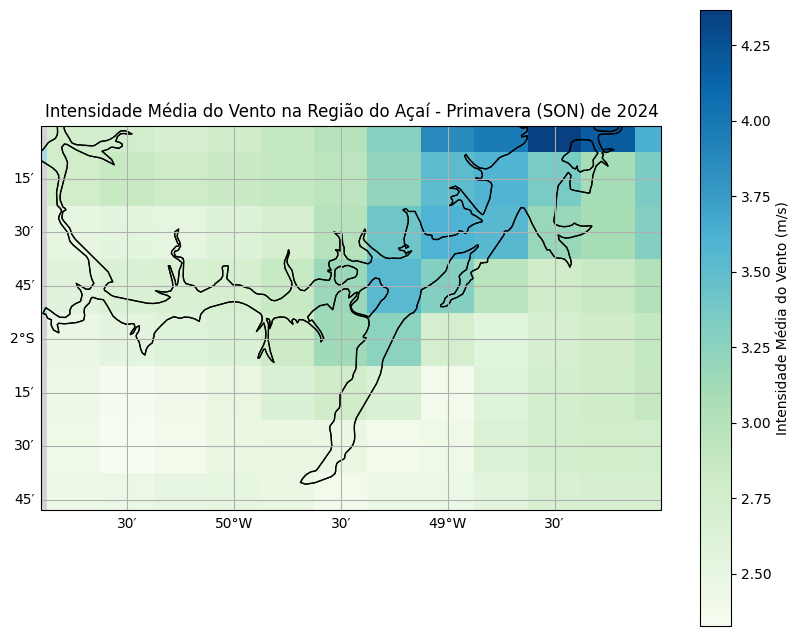

In [41]:
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import xarray as xr
import numpy as np # Import numpy for sqrt

# Define seasons with their corresponding months (Brazilian seasons)
seasons = {
    "Verão (DJF)": [12, 1, 2],    # December, January, February
    "Outono (MAM)": [3, 4, 5],     # March, April, May
    "Inverno (JJA)": [6, 7, 8],     # June, July, August
    "Primavera (SON)": [9, 10, 11]  # September, October, November
}

# Define the extent for the maps based on the data request area
# [lon_west, lon_east, lat_south, lat_north]
map_extent = [-50.9, -48, -2.8, -1] # This matches the 'area' requested in cdsapi

for season_name, months in seasons.items():
    # Filter data for the current season
    # Use .dt.month to extract month from valid_time and filter
    seasonal_df = df2.sel(valid_time=df2['valid_time'].dt.month.isin(months))

    # Calculate wind intensity (speed) from u10 and v10 components
    # Intensity = sqrt(u^2 + v^2)
    seasonal_wind_intensity = np.sqrt(seasonal_df['u10']**2 + seasonal_df['v10']**2).mean(dim='valid_time')

    # Create the plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree()) # Use PlateCarree projection

    # Set map extent
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())

    # Add geographical features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='black', linewidth=1.0)

    # Plot wind intensity data using pcolormesh for gridded data
    seasonal_wind_intensity.plot.pcolormesh(
        ax=ax,
        x='longitude',
        y='latitude',
        cmap='GnBu', # 'GnBu' or 'viridis' colormap is good for wind intensity, darker for stronger
        cbar_kwargs={'label': 'Intensidade Média do Vento (m/s)'},
        transform=ccrs.PlateCarree()
    )

    # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False # Hide top latitude labels
    gl.right_labels = False # Hide right longitude labels

    # Add title
    plt.title(f'Intensidade Média do Vento na Região do Açaí - {season_name} de 2024')

    plt.show()

### Umidade

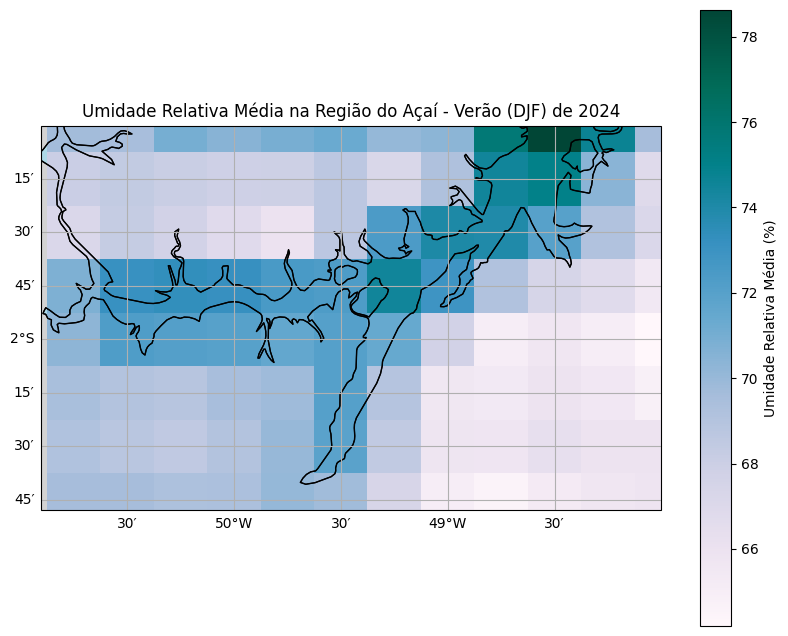

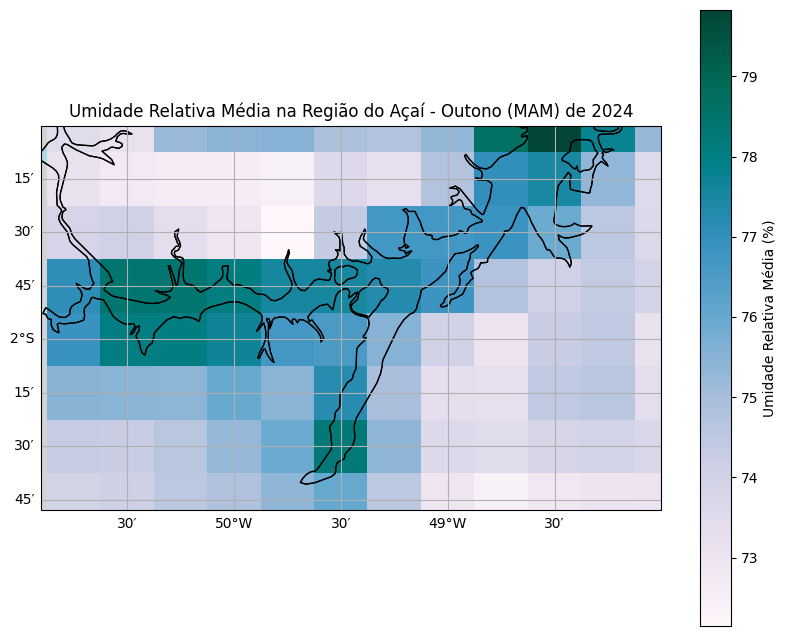

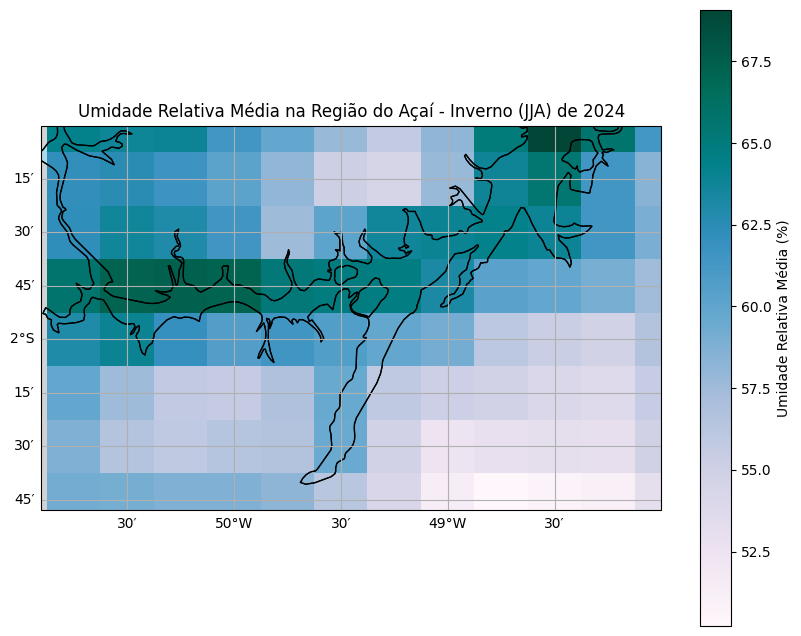

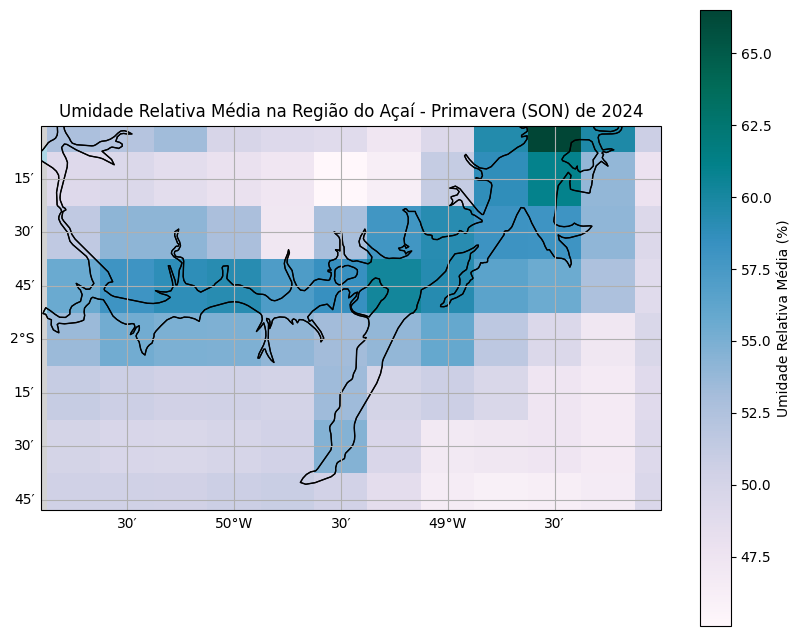

In [42]:
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cartopy.crs as ccrs
import xarray as xr
import numpy as np

# Define seasons with their corresponding months (Brazilian seasons)
seasons = {
    "Verão (DJF)": [12, 1, 2],    # December, January, February
    "Outono (MAM)": [3, 4, 5],     # March, April, May
    "Inverno (JJA)": [6, 7, 8],     # June, July, August
    "Primavera (SON)": [9, 10, 11]  # September, October, November
}

# Define the extent for the maps based on the data request area
map_extent = [-50.9, -48, -2.8, -1] # This matches the 'area' requested in cdsapi

for season_name, months in seasons.items():
    # Filter data for the current season
    seasonal_df = df2.sel(valid_time=df2['valid_time'].dt.month.isin(months))

    # Get 2m temperature and 2m dewpoint temperature in Kelvin
    t2m_kelvin = seasonal_df['t2m']
    d2m_kelvin = seasonal_df['d2m']

    # Convert to Celsius for the humidity calculation formula
    t2m_celsius = t2m_kelvin - 273.15
    d2m_celsius = d2m_kelvin - 273.15

    # Calculate saturation vapor pressure (es) and actual vapor pressure (e)
    # using the Magnus-Tetens formula (approximation)
    e_actual = 6.1078 * np.exp((17.27 * d2m_celsius) / (d2m_celsius + 237.3))
    e_saturation = 6.1078 * np.exp((17.27 * t2m_celsius) / (t2m_celsius + 237.3))

    # Calculate relative humidity (%)
    # Ensure to handle potential division by zero or very small es values
    # Also, clamp RH between 0 and 100 for realistic physical values
    relative_humidity = (e_actual / e_saturation) * 100
    relative_humidity = relative_humidity.where(e_saturation != 0, other=0) # Handle division by zero
    relative_humidity = relative_humidity.clip(0, 100) # Clamp values between 0 and 100%

    # Calculate the mean relative humidity for the season
    mean_seasonal_relative_humidity = relative_humidity.mean(dim='valid_time')

    # Create the plot
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

    # Set map extent
    ax.set_extent(map_extent, crs=ccrs.PlateCarree())

    # Add geographical features
    ax.add_feature(cfeature.LAND, facecolor="lightgray")
    ax.add_feature(cfeature.OCEAN, facecolor="lightblue")
    ax.coastlines(resolution='10m', linewidth=0.8)
    ax.add_feature(cfeature.BORDERS, linestyle='-', edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.STATES, linestyle='-', edgecolor='black', linewidth=1.0)

    # Plot relative humidity data
    mean_seasonal_relative_humidity.plot.pcolormesh(
        ax=ax,
        x='longitude',
        y='latitude',
        cmap='PuBuGn', # 'PuBuGn' colormap is good for humidity, darker = higher humidity
        cbar_kwargs={'label': 'Umidade Relativa Média (%)'},
        transform=ccrs.PlateCarree()
    )

    # Add gridlines with labels
    gl = ax.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)
    gl.top_labels = False
    gl.right_labels = False

    # Add title
    plt.title(f'Umidade Relativa Média na Região do Açaí - {season_name} de 2024')

    plt.show()